# ## ------------------------------------  MARY VISUALIZATIONS, MAP AND ML MODEL--------------------------------

**PARAMETERS**

In [1]:
WQ_path = "/kaggle/input/water-potability/water_potability.csv"

**LIBRARY**

In [2]:
pip install dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 61.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Basic
import numpy as np
import pandas as pd
from warnings import filterwarnings
from collections import Counter

# VISUALS
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.offline as pyo
import plotly.express as px
import plotly.graph_objs as go
#pyo.init_notebook_mode()
import plotly.figure_factory as ff
import missingno as msno

# PROCESSING
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split

# ML
from sklearn.linear_model import LogisticRegression,RidgeClassifier,SGDClassifier,PassiveAggressiveClassifier
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC,LinearSVC,NuSVC
from sklearn.neighbors import KNeighborsClassifier,NearestCentroid
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB,BernoulliNB
from sklearn.ensemble import VotingClassifier

# EVALUATION
from sklearn.metrics import precision_score,accuracy_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV,RepeatedStratifiedKFold

# DASH
import dash
from dash import Dash, dcc, html, Input, Output, callback

**COLORS**

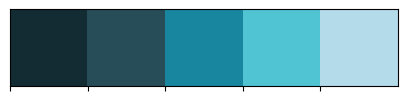

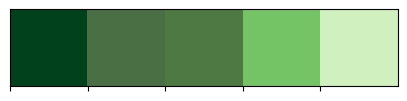

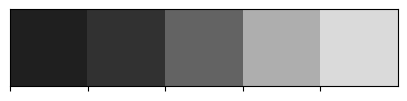

In [4]:
colors_blue = ["#132C33", "#264D58", '#17869E', '#51C4D3', '#B4DBE9']
colors_dark = ["#1F1F1F", "#313131", '#636363', '#AEAEAE', '#DADADA']
colors_green = ['#01411C','#4B6F44','#4F7942','#74C365','#D0F0C0']
sns.palplot(colors_blue)
sns.palplot(colors_green)
sns.palplot(colors_dark)

**DATA**

In [5]:
WQ_mock_read = pd.read_csv("/kaggle/input/water-potability/water_potability.csv")

In [6]:
WQ_mock_read.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690300,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833605,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762125,8.114887,359.950170,481.792305,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196010,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [7]:
WQ_mock_read.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


**VISUALS**

DF for 'Potability'

In [8]:
d = pd.DataFrame(WQ_mock_read['Potability'].value_counts()).reset_index()
d.columns = ['Potability', 'Count']
graph_names = []
graphs = []

PIE CHART

In [9]:
fig1 = px.pie(
    d, 
    values='Count', 
    names=['Not Potable', 'Potable'], 
    hole=0.4, 
    opacity=0.6,
    color_discrete_sequence=[colors_green[3], colors_blue[3]],
    labels={'label': 'Potability', 'Potability': 'No. Of Samples'}
)

In [10]:
fig1.update_layout(
    font_family='monospace',
    title=dict(
        text='Q. What is the Potablability of Water Samples?',
        x=0.47, y=0.98,
        font=dict(color=colors_dark[2], size=20)
    ),
    legend=dict(x=0.37, y=-0.05, orientation='h', traceorder='reversed'),
    hoverlabel=dict(bgcolor='white')
)

fig1.update_traces(textposition='outside', textinfo='percent+label')

graph_names.append(fig1.layout.title.text)
graphs.append(fig1)

HISTO (s)

**Hardness of water**: The simple definition of water hardness is the amount of dissolved calcium and magnesium in the water. Hard water is high in dissolved minerals, largely calcium and magnesium. You may have felt the effects of hard water, literally, the last time you washed your hands. Depending on the hardness of your water, after using soap to wash you may have felt like there was a film of residue left on your hands. In hard water, soap reacts with the calcium (which is relatively high in hard water) to form "soap scum". When using hard water, more soap or detergent is needed to get things clean, be it your hands, hair, or your laundry.

In [11]:
fig2 = px.histogram(
    WQ_mock_read,
    x='Hardness',
    color='Potability',
    template='plotly_white',
    marginal='box',
    opacity=0.7,
    nbins=100,
    color_discrete_sequence=[colors_green[3], colors_blue[3]],
    barmode='group',
    histfunc='count'
)

/opt/conda/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [12]:
fig2.add_annotation(
    text='<76 mg/L is<br> considered soft',
    x=40, y=130,
    showarrow=False,
    font_size=9
)
fig2.add_annotation(
    text='Between 76 and 150<br> (mg/L) is<br>moderately hard',
    x=113, y=130,
    showarrow=False,
    font_size=9
)
fig2.add_annotation(
    text='Between 151 and 300 (mg/L)<br> is considered hard',
    x=250, y=130,
    showarrow=False,
    font_size=9
)
fig2.add_annotation(
    text='>300 mg/L is<br> considered very hard',
    x=340, y=130,
    showarrow=False,
    font_size=9
)

In [13]:
fig2.update_layout(
    font_family='monospace',
    title=dict(
        text='Hardness Distribution',
        x=0.53, y=0.95,
        font=dict(color=colors_dark[2], size=20)
    ),
    xaxis_title_text='Hardness (mg/L)',
    yaxis_title_text='Count',
    legend=dict(
        x=1, y=0.96,
        bordercolor=colors_dark[4],
        borderwidth=0,
        tracegroupgap=5
    ),
    bargap=0.3,
)

graph_names.append(fig2.layout.title.text)
graphs.append(fig2)

**TDS**: TDS means concentration of dissolved particles or solids in water. TDS comprises of inorganic salts such as calcium, magnesium, chlorides, sulfates, bicarbonates, etc, along with many more inorganic compounds that easily dissolve in water.

In [14]:
fig3 = px.histogram(
    WQ_mock_read,
    x='Solids',
    color='Potability',
    template='plotly_white',
    marginal='box',
    opacity=0.7,
    nbins=100,
    color_discrete_sequence=[colors_green[3], colors_blue[3]],
    barmode='group',
    histfunc='count'
)

/opt/conda/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [15]:
fig3.update_layout(
    font_family='monospace',
    title=dict(
        text='Distribution Of Total Dissolved Solids',
        x=0.5, y=0.95,
        font=dict(color=colors_dark[2], size=20)
    ),
    xaxis_title_text='Dissolved Solids (ppm)',
    yaxis_title_text='Count',
    legend=dict(
        x=1, y=0.96,
        bordercolor=colors_dark[4],
        borderwidth=0,
        tracegroupgap=5
    ),
    bargap=0.3,
)

In [16]:
graph_names.append(fig3.layout.title.text)
graphs.append(fig3)

**Chloramines**: Chloramines (also known as secondary disinfection) are disinfectants used to treat drinking water and they:

* Are most commonly formed when ammonia is added to chlorine to treat drinking water.
* Provide longer-lasting disinfection as the water moves through pipes to consumers.

Chloramines have been used by water utilities since the 1930s.

In [17]:
fig4 = px.histogram(
    WQ_mock_read,
    x='Chloramines',
    color='Potability',
    template='plotly_white',
    marginal='box',
    opacity=0.7,
    nbins=100,
    color_discrete_sequence=[colors_green[3], colors_blue[3]],
    barmode='group',
    histfunc='count'
)

/opt/conda/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [18]:
fig4.add_vline(x=4, line_width=1, line_color=colors_dark[1],line_dash='dot',opacity=0.7)

fig4.add_annotation(text='<4 ppm is considered<br> safe for drinking',x=1.8,y=90,showarrow=False)

fig4.update_layout(
    font_family='monospace',
    title=dict(text='Chloramines Distribution',x=0.53,y=0.95,
               font=dict(color=colors_dark[2],size=20)),
    xaxis_title_text='Chloramines (ppm)',
    yaxis_title_text='Count',
    legend=dict(x=1,y=0.96,bordercolor=colors_dark[4],borderwidth=0,tracegroupgap=5),
    bargap=0.3,
)

graph_names.append(fig4.layout.title.text)
graphs.append(fig4)

**Sulfate**: Sulfate (SO4) can be found in almost all natural water. The origin of most sulfate compounds is the oxidation of sulfite ores, the presence of shales, or the industrial wastes.
Sulfate is one of the major dissolved components of rain. High concentrations of sulfate in the water we drink can have a laxative effect when combined with calcium and magnesium, the two most common constituents of hardness.

In [19]:
fig5 = px.histogram(
    WQ_mock_read,
    x='Sulfate',
    color='Potability',
    template='plotly_white',
    marginal='box',
    opacity=0.7,
    nbins=100,
    color_discrete_sequence=[colors_green[3], colors_blue[3]],
    barmode='group',
    histfunc='count'
)

/opt/conda/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [20]:
fig5.add_vline(x=250, line_width=1, line_color=colors_dark[1],line_dash='dot',opacity=0.7)

fig5.add_annotation(text='<250 mg/L is considered<br> safe for drinking',x=175,y=90,showarrow=False)

fig5.update_layout(
    font_family='monospace',
    title=dict(text='Sulfate Distribution',x=0.53,y=0.95,
               font=dict(color=colors_dark[2],size=20)),
    xaxis_title_text='Sulfate (mg/L)',
    yaxis_title_text='Count',
    legend=dict(x=1,y=0.96,bordercolor=colors_dark[4],borderwidth=0,tracegroupgap=5),
    bargap=0.3,
)

graph_names.append(fig5.layout.title.text)
graphs.append(fig5)

**Conductivity**: Conductivity is a measure of the ability of water to pass an electrical current. Because dissolved salts and other inorganic chemicals conduct electrical current, conductivity increases as salinity increases. Organic compounds like oil do not conduct electrical current very well and therefore have a low conductivity when in water. Conductivity is also affected by temperature: the warmer the water, the higher the conductivity.

In [21]:
fig6 = px.histogram(
    WQ_mock_read,
    x='Conductivity',
    color='Potability',
    template='plotly_white',
    marginal='box',
    opacity=0.7,
    nbins=100,
    color_discrete_sequence=[colors_green[3], colors_blue[3]],
    barmode='group',
    histfunc='count'
)

/opt/conda/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [22]:
fig6.add_annotation(text='The Conductivity range <br> is safe for both (200-800),<br> Potable and Non-Potable water',
                   x=600,y=90,showarrow=False)

fig6.update_layout(
    font_family='monospace',
    title=dict(text='Conductivity Distribution',x=0.5,y=0.95,
               font=dict(color=colors_dark[2],size=20)),
    xaxis_title_text='Conductivity (μS/cm)',
    yaxis_title_text='Count',
    legend=dict(x=1,y=0.96,bordercolor=colors_dark[4],borderwidth=0,tracegroupgap=5),
    bargap=0.3,
)

graph_names.append(fig6.layout.title.text)
graphs.append(fig6)

**Organic Carbon**: Organic contaminants (natural organic substances, insecticides, herbicides, and other agricultural chemicals) enter waterways in rainfall runoff. Domestic and industrial wastewaters also contribute organic contaminants in various amounts. As a result of accidental spills or leaks, industrial organic wastes may enter streams. Some of the contaminants may not be completely removed by treatment processes; therefore, they could become a problem for drinking water sources. It is important to know the organic content in a waterway.

In [23]:
fig7 = px.histogram(
    WQ_mock_read,
    x='Organic_carbon',
    color='Potability',
    template='plotly_white',
    marginal='box',
    opacity=0.7,
    nbins=100,
    color_discrete_sequence=[colors_green[3], colors_blue[3]],
    barmode='group',
    histfunc='count'
)

/opt/conda/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [24]:
fig7.add_vline(x=10, line_width=1, line_color=colors_dark[1],line_dash='dot',opacity=0.7)

fig7.add_annotation(text='Typical Organic Carbon<br> level is upto 10 ppm',x=5.3,y=110,showarrow=False)

fig7.update_layout(
    font_family='monospace',
    title=dict(text='Organic Carbon Distribution',x=0.5,y=0.95,
               font=dict(color=colors_dark[2],size=20)),
    xaxis_title_text='Organic Carbon (ppm)',
    yaxis_title_text='Count',
    legend=dict(x=1,y=0.96,bordercolor=colors_dark[4],borderwidth=0,tracegroupgap=5),
    bargap=0.3,
)

graph_names.append(fig7.layout.title.text)
graphs.append(fig7)

**Trihalomethanes**: Trihalomethanes (THMs) are the result of a reaction between the chlorine used for disinfecting tap water and natural organic matter in the water. At elevated levels, THMs have been associated with negative health effects such as cancer and adverse reproductive outcomes.

In [25]:
fig8 = px.histogram(
    WQ_mock_read,
    x='Trihalomethanes',
    color='Potability',
    template='plotly_white',
    marginal='box',
    opacity=0.7,
    nbins=100,
    color_discrete_sequence=[colors_green[3], colors_blue[3]],
    barmode='group',
    histfunc='count'
)

/opt/conda/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [26]:
fig8.add_vline(x=80, line_width=1, line_color=colors_dark[1],line_dash='dot',opacity=0.7)

fig8.add_annotation(text='Upper limit of Trihalomethanes<br> level is 80 μg/L',x=115,y=90,showarrow=False)

fig8.update_layout(
    font_family='monospace',
    title=dict(text='Trihalomethanes Distribution',x=0.5,y=0.95,
               font=dict(color=colors_dark[2],size=20)),
    xaxis_title_text='Trihalomethanes (μg/L)',
    yaxis_title_text='Count',
    legend=dict(x=1,y=0.96,bordercolor=colors_dark[4],borderwidth=0,tracegroupgap=5),
    bargap=0.3,
)

graph_names.append(fig8.layout.title.text)
graphs.append(fig8)

**Turbidity**: Turbidity is the measure of relative clarity of a liquid. It is an optical characteristic of water and is a measurement of the amount of light that is scattered by material in the water when a light is shined through the water sample. The higher the intensity of scattered light, the higher the turbidity. Material that causes water to be turbid include clay, silt, very tiny inorganic and organic matter, algae, dissolved colored organic compounds, and plankton and other microscopic organisms.

In [27]:
fig9 = px.histogram(
    WQ_mock_read,
    x='Turbidity',
    color='Potability',
    template='plotly_white',
    marginal='box',
    opacity=0.7,
    nbins=100,
    color_discrete_sequence=[colors_green[3], colors_blue[3]],
    barmode='group',
    histfunc='count'
)

/opt/conda/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [28]:
fig9.add_vline(x=5, line_width=1, line_color=colors_dark[1],line_dash='dot',opacity=0.7)

fig9.add_annotation(text='<5 NTU Turbidity is<br> considered safe',x=6,y=90,showarrow=False)

fig9.update_layout(
    font_family='monospace',
    title=dict(text='Turbidity Distribution',x=0.5,y=0.95,
               font=dict(color=colors_dark[2],size=20)),
    xaxis_title_text='Turbidity (NTU)',
    yaxis_title_text='Count',
    legend=dict(x=1,y=0.96,bordercolor=colors_dark[4],borderwidth=0,tracegroupgap=5),
    bargap=0.3,
)

graph_names.append(fig9.layout.title.text)
graphs.append(fig9)

## ----------------------------------MARY ML INTEGRATION----------------------------------------------------------

## CLEAN

In [29]:
# fig = msno.matrix(WQ_mock_read,color=(0,0.5,0.5))

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:29:38.924648Z","iopub.execute_input":"2024-05-22T19:29:38.925054Z","iopub.status.idle":"2024-05-22T19:29:38.934935Z","shell.execute_reply.started":"2024-05-22T19:29:38.925023Z","shell.execute_reply":"2024-05-22T19:29:38.933719Z"}}
# WQ_mock_read.isnull().sum()

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:29:45.091145Z","iopub.execute_input":"2024-05-22T19:29:45.091522Z","iopub.status.idle":"2024-05-22T19:29:45.128069Z","shell.execute_reply.started":"2024-05-22T19:29:45.091494Z","shell.execute_reply":"2024-05-22T19:29:45.127278Z"}}
# WQ_mock_read[WQ_mock_read['Potability']==0].describe()

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:30:14.908083Z","iopub.execute_input":"2024-05-22T19:30:14.908454Z","iopub.status.idle":"2024-05-22T19:30:14.947181Z","shell.execute_reply.started":"2024-05-22T19:30:14.908427Z","shell.execute_reply":"2024-05-22T19:30:14.946306Z"}}
# WQ_mock_read[WQ_mock_read['Potability']==1].describe()

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:30:21.607604Z","iopub.execute_input":"2024-05-22T19:30:21.607989Z","iopub.status.idle":"2024-05-22T19:30:21.619924Z","shell.execute_reply.started":"2024-05-22T19:30:21.607960Z","shell.execute_reply":"2024-05-22T19:30:21.618894Z"}}
# WQ_mock_read[WQ_mock_read['Potability']==0][['ph','Sulfate','Trihalomethanes']].median()

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:30:51.234419Z","iopub.execute_input":"2024-05-22T19:30:51.234846Z","iopub.status.idle":"2024-05-22T19:30:51.247601Z","shell.execute_reply.started":"2024-05-22T19:30:51.234814Z","shell.execute_reply":"2024-05-22T19:30:51.246364Z"}}
# WQ_mock_read[WQ_mock_read['Potability']==1][['ph','Sulfate','Trihalomethanes']].median()

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:30:54.674121Z","iopub.execute_input":"2024-05-22T19:30:54.674516Z","iopub.status.idle":"2024-05-22T19:30:54.683230Z","shell.execute_reply.started":"2024-05-22T19:30:54.674485Z","shell.execute_reply":"2024-05-22T19:30:54.682194Z"}}
# WQ_mock_read['ph'].fillna(value=WQ_mock_read['ph'].median(),inplace=True)
# WQ_mock_read['Sulfate'].fillna(value=WQ_mock_read['Sulfate'].median(),inplace=True)
# WQ_mock_read['Trihalomethanes'].fillna(value=WQ_mock_read['Trihalomethanes'].median(),inplace=True)

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:31:36.463422Z","iopub.execute_input":"2024-05-22T19:31:36.463798Z","iopub.status.idle":"2024-05-22T19:31:36.472345Z","shell.execute_reply.started":"2024-05-22T19:31:36.463770Z","shell.execute_reply":"2024-05-22T19:31:36.471518Z"}}
# WQ_mock_read.isnull().sum()

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:31:43.403448Z","iopub.execute_input":"2024-05-22T19:31:43.403827Z","iopub.status.idle":"2024-05-22T19:31:43.409946Z","shell.execute_reply.started":"2024-05-22T19:31:43.403800Z","shell.execute_reply":"2024-05-22T19:31:43.408756Z"}}
# X = WQ_mock_read.drop('Potability',axis=1).values
# y = WQ_mock_read['Potability'].values

### MACHINE LEARNING MODEL

SPLIT

In [30]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# # %% [markdown]
# # STANDARDIZE

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:32:07.488529Z","iopub.execute_input":"2024-05-22T19:32:07.489001Z","iopub.status.idle":"2024-05-22T19:32:07.497402Z","shell.execute_reply.started":"2024-05-22T19:32:07.488953Z","shell.execute_reply":"2024-05-22T19:32:07.496191Z"}}
# scaler = StandardScaler()
# scaler.fit(X_train)
# X_train = scaler.transform(X_train)
# X_test = scaler.transform(X_test)

# # %% [markdown]
# # ## LOGISTIC REG

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:32:13.175731Z","iopub.execute_input":"2024-05-22T19:32:13.176095Z","iopub.status.idle":"2024-05-22T19:32:16.546846Z","shell.execute_reply.started":"2024-05-22T19:32:13.176066Z","shell.execute_reply":"2024-05-22T19:32:16.545783Z"}}
# filterwarnings('ignore')
# models =[("LR", LogisticRegression(max_iter=1000)),("SVC", SVC()),('KNN',KNeighborsClassifier(n_neighbors=10)),
#          ("DTC", DecisionTreeClassifier()),("GNB", GaussianNB()),
#         ("SGDC", SGDClassifier()),("Perc", Perceptron()),("NC",NearestCentroid()),
#         ("Ridge", RidgeClassifier()),("NuSVC", NuSVC()),("BNB", BernoulliNB()),
#          ('RF',RandomForestClassifier()),('ADA',AdaBoostClassifier()),
#         ('XGB',GradientBoostingClassifier()),('PAC',PassiveAggressiveClassifier())]

# results = []
# names = []
# finalResults = []

# for name,model in models:
#     model.fit(X_train, y_train)
#     model_results = model.predict(X_test)
#     score = precision_score(y_test, model_results,average='macro')
#     results.append(score)
#     names.append(name)
#     finalResults.append((name,score))
    
# finalResults.sort(key=lambda k:k[1],reverse=True)

# # %% [markdown]
# # **PREDICTIVE OUTPUT**

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:32:19.833031Z","iopub.execute_input":"2024-05-22T19:32:19.833405Z","iopub.status.idle":"2024-05-22T19:32:19.840560Z","shell.execute_reply.started":"2024-05-22T19:32:19.833377Z","shell.execute_reply":"2024-05-22T19:32:19.839401Z"}}
# finalResults

# # %% [markdown]
# # **HYPERPARAMETER TUNING**

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:34:52.956854Z","iopub.execute_input":"2024-05-22T19:34:52.957288Z","iopub.status.idle":"2024-05-22T19:34:52.967483Z","shell.execute_reply.started":"2024-05-22T19:34:52.957254Z","shell.execute_reply":"2024-05-22T19:34:52.966257Z"}}
# model_params = {
#     'XGB':
#     {
#         'model':GradientBoostingClassifier(),
#         'params':
#         {
#             'learning_rate':[0.0001,0.001,0.01,0.1],
#             'n_estimators':[100,200,500,1000],
#             'max_features':['sqrt','log2'],
#             'max_depth':list(range(11))
#         }
#     },
#     'Random Forest':
#     {
#         'model':RandomForestClassifier(),
#         'params':
#         {
#             'n_estimators':[10,50,100,200],
#             'max_features':['auto','sqrt','log2'],
#             'max_depth':list(range(1,11))
#         }
#     }
# }

# # %% [markdown]
# # RUN TIME ~ 10 MINS

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:35:05.480523Z","iopub.execute_input":"2024-05-22T19:35:05.481879Z","iopub.status.idle":"2024-05-22T19:45:58.418478Z","shell.execute_reply.started":"2024-05-22T19:35:05.481831Z","shell.execute_reply":"2024-05-22T19:45:58.417327Z"}}
# cv = RepeatedStratifiedKFold(n_splits=5,n_repeats=2)
# scores=[]
# for model_name,params in model_params.items():
#     rs = RandomizedSearchCV(params['model'],params['params'],cv=cv,n_iter=20)
#     rs.fit(X,y)
#     scores.append([model_name,dict(rs.best_params_),rs.best_score_])
# data=pd.DataFrame(scores,columns=['Model','Parameters','Score'])
# data

# # %% [markdown]
# # **VOTING CLASSIFER**

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:45:58.420531Z","iopub.execute_input":"2024-05-22T19:45:58.421242Z","iopub.status.idle":"2024-05-22T19:47:10.817320Z","shell.execute_reply.started":"2024-05-22T19:45:58.421198Z","shell.execute_reply":"2024-05-22T19:47:10.816313Z"}}
# param=data['Parameters']
# model = VotingClassifier(estimators=[
#                                      ('XGB',GradientBoostingClassifier(**param[0])),
#                                      ('RF',RandomForestClassifier(**param[1])),
#                                     ],voting='hard')

# accuracy=[]
# scaler = StandardScaler()
# skf = RepeatedStratifiedKFold(n_splits=5,n_repeats=2)
# skf.get_n_splits(X,y)

# for train_index, test_index in skf.split(X,y):
    
#     X_train, X_test = X[train_index], X[test_index]
#     y_train, y_test = y[train_index], y[test_index]
    
#     scaler.fit(X_train)
#     X_train = scaler.transform(X_train)
#     X_test = scaler.transform(X_test)
    
#     model.fit(X_train,y_train)
#     predictions=model.predict(X_test)
#     score=accuracy_score(y_test,predictions)
#     accuracy.append(score)

# # %% [markdown]
# # **ACCURACY SCORE**

# # %% [code] {"jupyter":{"outputs_hidden":false},"execution":{"iopub.status.busy":"2024-05-22T19:54:14.505736Z","iopub.execute_input":"2024-05-22T19:54:14.506124Z","iopub.status.idle":"2024-05-22T19:54:14.512327Z","shell.execute_reply.started":"2024-05-22T19:54:14.506097Z","shell.execute_reply":"2024-05-22T19:54:14.511007Z"}}
# np.mean(accuracy)
# print(accuracy)

## TEXT FOR DASH

1. The TDS levels seem to contain some descripency since its values are on an average 40 folds more than the upper limit for safe drinking water.

2. The data contains almost equal number of acidic and basic pH level water samples.

3. 92% of the data was considered Hard. 

4. Only 2% of the water samples were safe in terms of Chloramines levels.

5. Only 1.8% of the water samples were safe in terms of Sulfate levels.

6. 90.6% of the water samples had higher Carbon levels than the typical Carbon levels in drinking water (10 ppm).

7. 76.6% of water samples were safe for drinking in terms of Trihalomethane levels in water.

8. 90.4% of the water samples were safe for drinking in terms of the Turbidity of water samples.

9. The correlation coefficients between the features were very low.

10. Random Forest and XGBoost worked the best to train the model.

11. The ensemble method of using the Voting Classfier on Stratified K-folded samples gave an accuracy of >64%, not bad!

## END WITH DASH CODE TO INCLUDE ALL VISUALS AND TEXT

**VISUALS**

In [31]:
fig_chloramines = px.histogram(
    WQ_mock_read,
    x='Chloramines',
    color='Potability',
    template='plotly_white',
    marginal='box',
    opacity=0.7,
    nbins=100,
    color_discrete_sequence=[colors_green[3], colors_blue[3]],
    barmode='group',
    histfunc='count'
)
fig_chloramines.add_vline(x=4, line_width=1, line_color=colors_dark[1], line_dash='dot', opacity=0.7)
fig_chloramines.add_annotation(text='<4 ppm is considered<br> safe for drinking', x=1.8, y=90, showarrow=False)
fig_chloramines.update_layout(
    font_family='monospace',
    title=dict(text='Chloramines Distribution', x=0.53, y=0.95, font=dict(color=colors_dark[2], size=20)),
    xaxis_title_text='Chloramines (ppm)',
    yaxis_title_text='Count',
    legend=dict(x=1, y=0.96, bordercolor=colors_dark[4], borderwidth=0, tracegroupgap=5),
    bargap=0.3,
)

fig_trihalomethanes = px.histogram(
    WQ_mock_read,
    x='Trihalomethanes',
    color='Potability',
    template='plotly_white',
    marginal='box',
    opacity=0.7,
    nbins=100,
    color_discrete_sequence=[colors_green[3], colors_blue[3]],
    barmode='group',
    histfunc='count'
)
fig_trihalomethanes.update_layout(
    font_family='monospace',
    title=dict(text='Trihalomethanes Distribution', x=0.53, y=0.95, font=dict(color=colors_dark[2], size=20)),
    xaxis_title_text='Trihalomethanes (ppm)',
    yaxis_title_text='Count',
    legend=dict(x=1, y=0.96, bordercolor=colors_dark[4], borderwidth=0, tracegroupgap=5),
    bargap=0.3,
)

/opt/conda/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/opt/conda/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



**DASH APP**

In [32]:
# Clifton Wells Demo Geospatial Data
df = pd.read_csv('/kaggle/input/clifton-wells-demo-csv/clifton_wells_demo.csv')

# Create a Plotly figure using Mapbox
clifton_wells_map = px.scatter_mapbox(
    df,
    lat='Latitude',
    lon='Longitude',
    hover_name='Name',
    zoom=10,
    height=600
)

# Update the layout to use the Mapbox token
clifton_wells_map.update_layout(
    mapbox=dict(
        accesstoken='pk.eyJ1IjoiY29vcGVyLXAiLCJhIjoiY2x3a3Y4c2k5MDh5bjJqcGIycXV6Znl3biJ9.4J3P3HOVVTiVaY_lW5Ew2Q',
        style='satellite-streets'  # You can use 'satellite', 'outdoors', 'light', etc.
    ),
    margin=dict(l=0, r=0, t=0, b=0)
)

In [33]:
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1(
        "Water Quality Analysis Dashboard",
        style={'textAlign': 'center', 'color': '#5ba400', 'font-size': '60px'}
    ),
    html.Div(
        dcc.Dropdown(
            graph_names,
            graph_names[0],
            id='graph name dropdown',
            style={'width': '100%'}
        ),
        style={'textAlign': 'center', 'width': '20%', 'display': 'inline-block'}
    ),
    dcc.Graph(id='graph'),
    dcc.Graph(id='interactive map', figure=clifton_wells_map)
])

@callback(
    Output('graph', 'figure'),
    Input('graph name dropdown', 'value'))
def update_figure(selected_graph):
    fig = graphs[graph_names.index(selected_graph)]
    fig.update_layout(transition_duration=500)
    return fig

if __name__ == '__main__':
    app.run(host='0.0.0.0', debug=True)

**SAVE FILE**

In [34]:
#python app.py

**DEPLOYMENT**

In [35]:
# web: gunicorn app:app

In [36]:
#pip freeze > requirements.txt

In [37]:
#heroku create
#git add .
#git commit -m "Initial commit"
#git push heroku master